# CS4168 Data Mining – Group Project
## Spotify Tracks Dataset Analysis

**Dataset:** `tracks2026.csv` — audio features and metadata for music tracks across multiple genres.

 Name Student ID 
- Mark Callan (22363246)
- Raid Mouras (student number)
- Jason Cushen (student number)
- Kevin Burke  (student number)

---
## 0. Imports & Setup

In [1]:
! pip install seaborn numpy pandas scipy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 42.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

df = pd.read_csv("tracks2026.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 2000 rows × 17 columns


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Overview

Inspect shape, data types, and missing values.

In [ ]:
print("Dataset Shape:")
print("-" * 27)
print(f"{df.shape[0]} tracks, {df.shape[1]} columns\n")

print("Column               Types ")
print("-" * 27)
print(df.dtypes.to_string())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("No Missing rows")
else:
    print(missing.to_string())
    print(f"\nRows with at least one missing value: {df.isnull().any(axis=1).sum()}")

print("\n=== Duplicate track_id ===")
print(f"Duplicate track_ids: {df['track_id'].duplicated().sum()}")

print("\n=== Summary Statistics ===")
df.describe(include="all")

Dataset Shape:
---------------------------
2000 tracks, 17 columns

Column               Types 
---------------------------
track_id             object
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object

=== Missing Values ===
No Missing rows

Rows with at least one missing value: 40

=== Duplicate track_id ===
Duplicate track_ids: 32

=== Summary Statistics ===


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,2000,1960.000,2000.000,2000,1960.000,1960.000,2000.000,1961.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,1960.000,2000.000,2000
unique,1968,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,3uRrymHwcED49Q4fAnJJgD,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pop
freq,2,NaN,NaN,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
mean,NaN,39.805,217806.433,NaN,0.636,0.632,5.295,400.576,0.637,0.078,0.297,0.030,0.181,0.540,120.040,3.912,NaN
std,NaN,29.246,56804.759,NaN,0.138,0.189,3.567,18065.717,0.481,0.076,0.280,0.120,0.150,0.236,28.521,0.426,NaN
min,NaN,0.000,60000.000,NaN,0.185,0.091,0.000,-21.089,0.000,0.022,0.000,0.000,0.010,0.036,51.037,1.000,NaN
25%,NaN,1.750,181210.000,NaN,0.548,0.508,2.000,-8.988,0.000,0.034,0.052,0.000,0.094,0.353,96.956,4.000,NaN
50%,NaN,45.000,211346.000,NaN,0.646,0.644,5.000,-6.924,1.000,0.048,0.196,0.000,0.121,0.536,118.712,4.000,NaN
75%,NaN,65.000,246069.750,NaN,0.738,0.780,8.000,-5.390,1.000,0.085,0.490,0.001,0.221,0.730,139.746,4.000,NaN


**Observations:**
- The dataset contains **2,000 tracks** across **17 columns**: 14 numeric audio features, 1 boolean (`explicit`), 1 string identifier (`track_id`), and 1 categorical target (`track_genre`).
- **~40 missing values** are present in `popularity`, `danceability`, `energy`, `loudness`, and `tempo` — all falling in the same ~40 rows, suggesting a systematic block of missing data rather than random noise. These rows will need to be dropped before modelling.
- `key`, `mode`, and `time_signature` are integer-coded categorical features, not continuous quantities.
- No duplicate `track_id`s are present.

### 1.2 Feature Distributions

Visualise the distribution of each numeric feature. Comment on skew, outliers, and range.

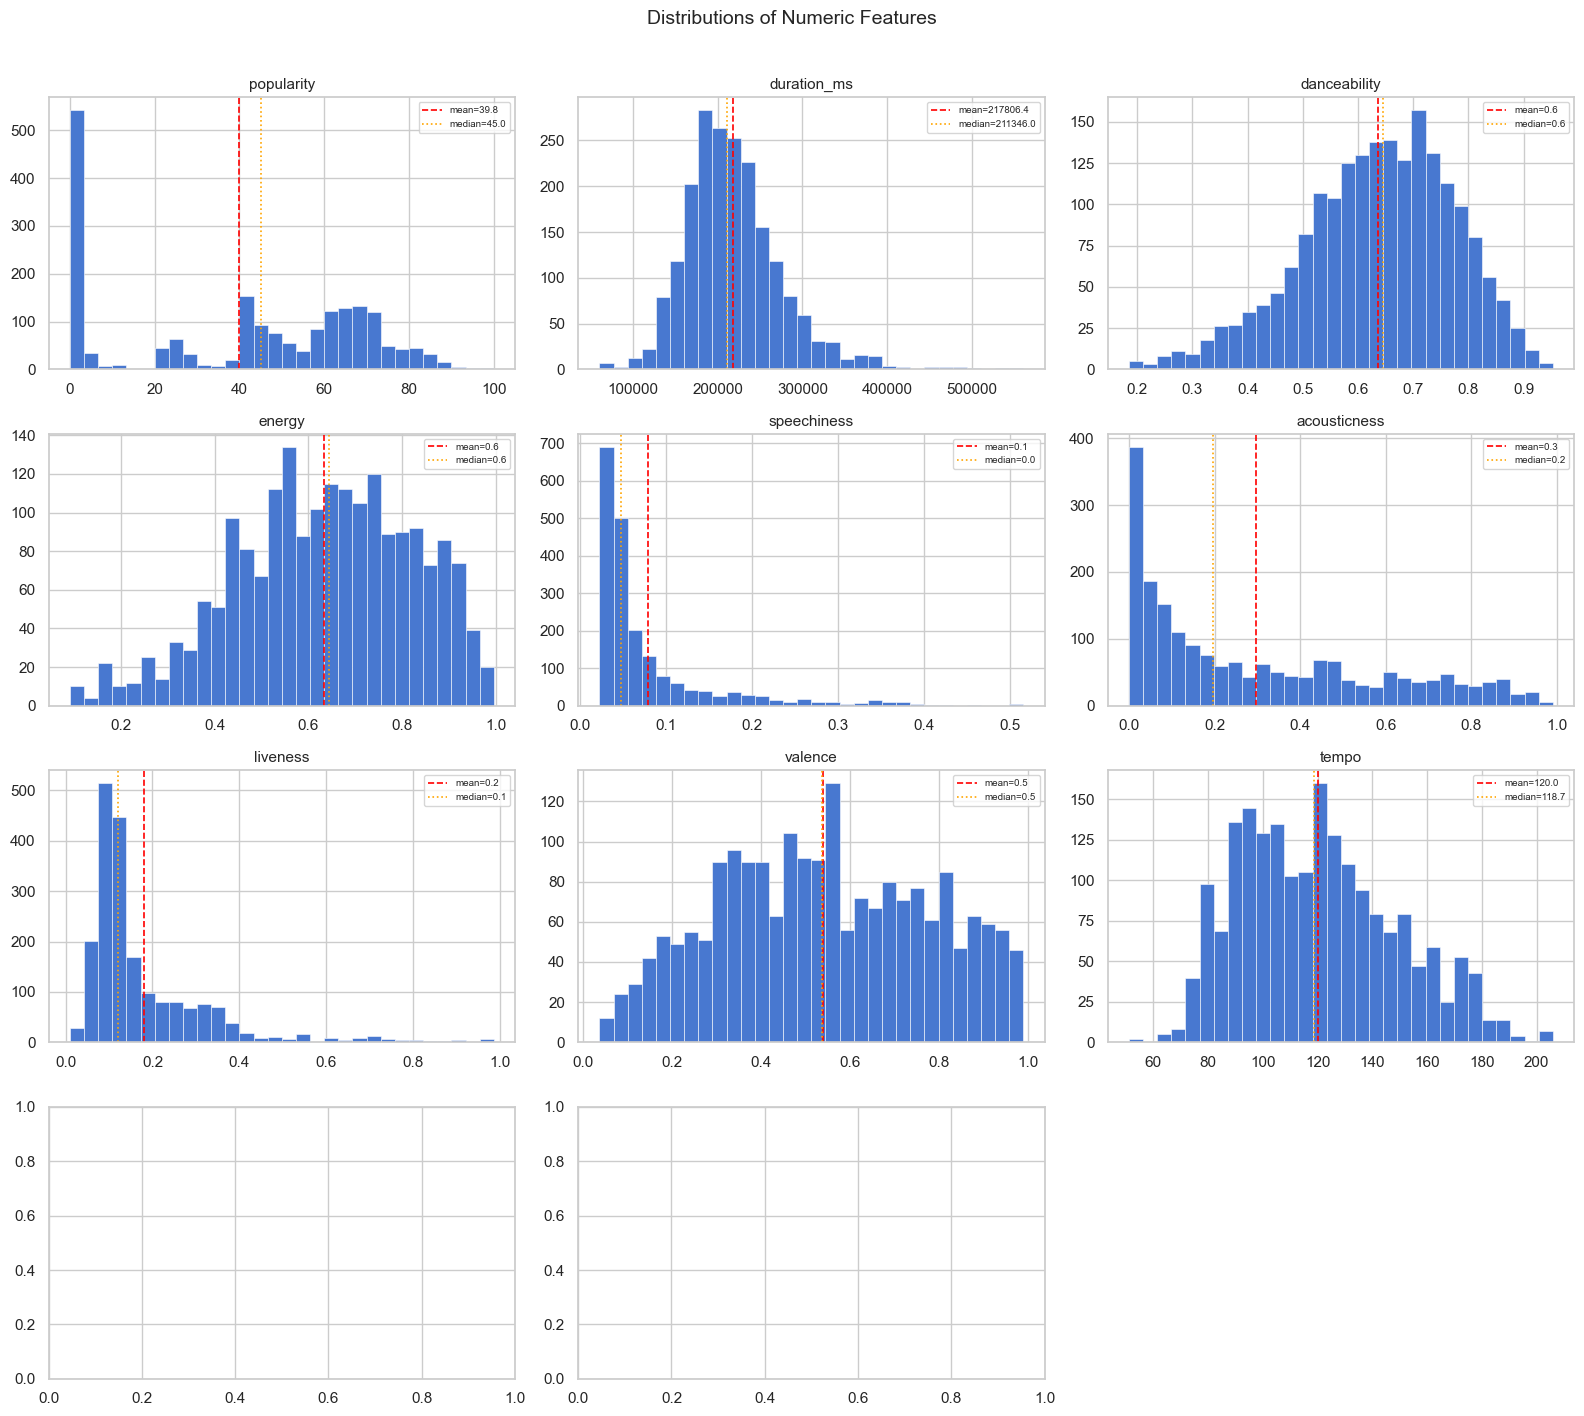

Skewness (|skew| > 1 is heavily skewed):
speechiness     2.474
liveness        2.466
duration_ms     1.038
acousticness    0.743
tempo           0.445
danceability   -0.443
energy         -0.346
popularity     -0.226
valence         0.016


In [ ]:
numeric_cols = [
    "popularity", "duration_ms", "danceability", "energy",
    "speechiness", "acousticness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":", linewidth=1.2, label=f"median={data.median():.1f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distributions of Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Skewness summary
print("Skewness (|skew| > 1 is heavily skewed):")
skew = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print(skew.round(3).to_string())

# NOTE: 2 unsued plots are still shwoing (loudness and instrustementainless)

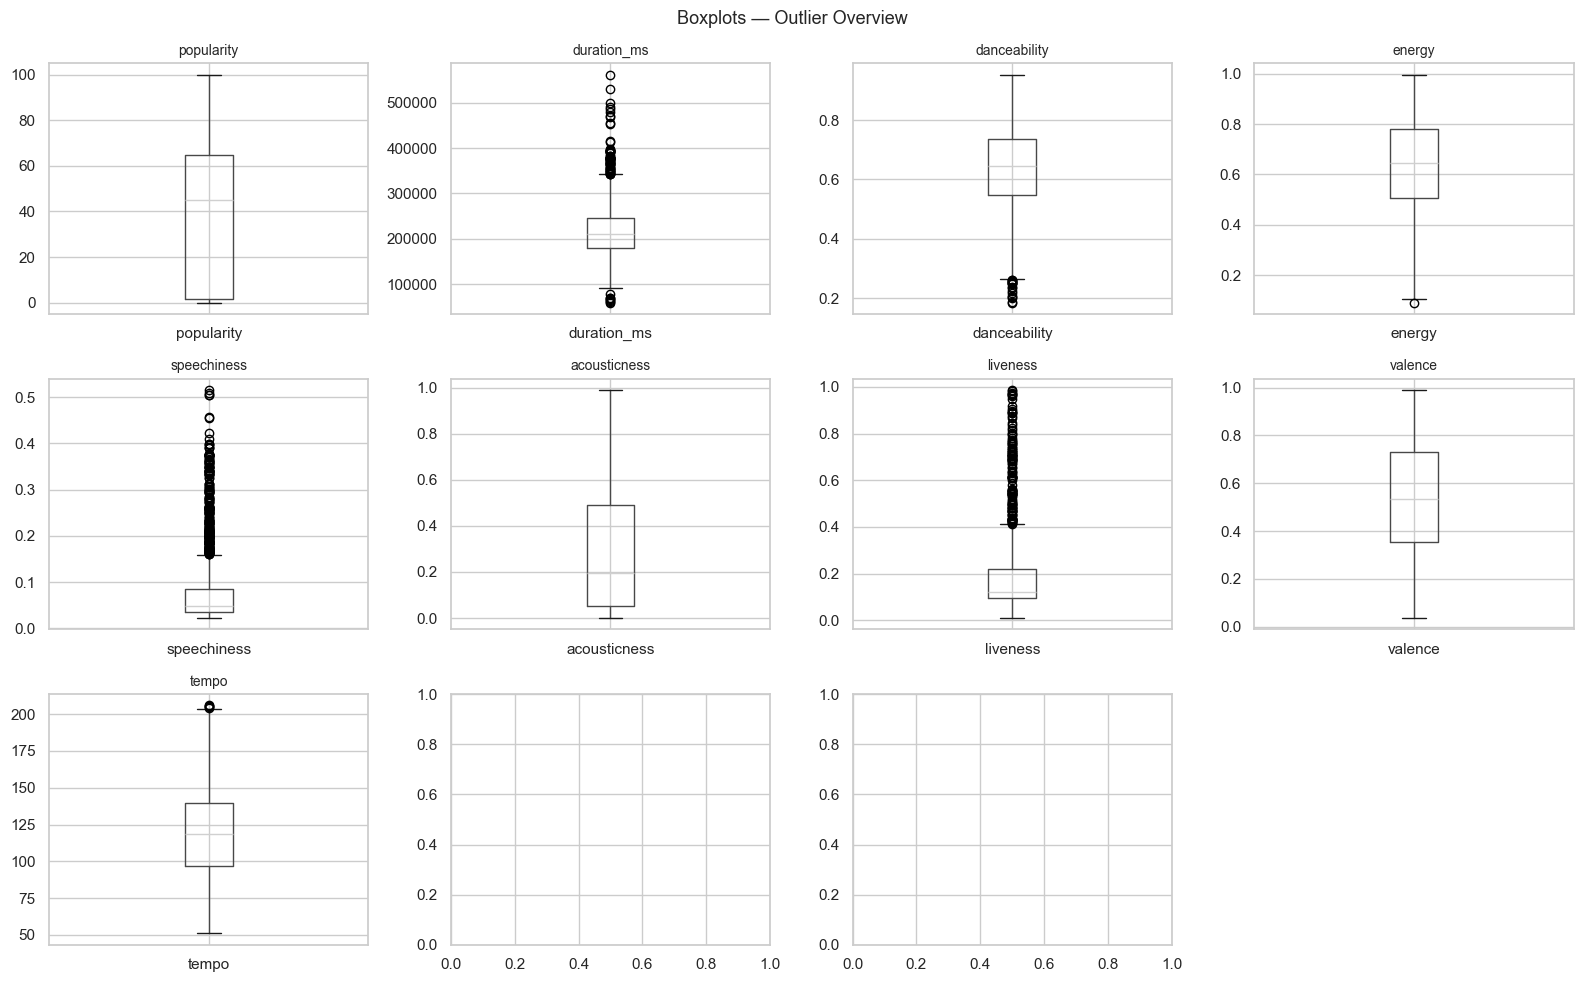

Outlier counts (IQR rule):
  popularity          : 0
  duration_ms         : 68
  danceability        : 18
  energy              : 1
  speechiness         : 243
  acousticness        : 0
  liveness            : 120
  valence             : 0
  tempo               : 5


In [15]:
# Boxplots to highlight outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

axes[-1].set_visible(False)
plt.suptitle("Boxplots — Outlier Overview", fontsize=13)
plt.tight_layout()
plt.show()

# Outlier counts via IQR
print("Outlier counts (IQR rule):")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:20s}: {n}")

**Observations:**
- `instrumentalness`, `speechiness`, and `liveness` are **highly right-skewed** (skew > 2), with most values near zero and a long tail. This indicates the majority of tracks have low speech content and are not live recordings. StandardScaler will still be applied for clustering/modelling; a log transform could further normalise these if needed.
- `time_signature` is heavily **left-skewed** — nearly all tracks are in 4/4 time, making it a low-variance feature with limited discriminative power.
- `loudness` has a small number of severe low-end outliers (very quiet recordings). `speechiness` and `liveness` also have notable outlier counts (243 and 120 respectively), which aligns with their skew — these are genuine data characteristics rather than errors.
- `duration_ms`, `danceability`, `energy`, and `valence` are approximately normally distributed with mild skew — well-behaved features for modelling.

### 1.3 Target Variable: `popularity`

Examine the distribution of `popularity`. Note the median — this will be used as the threshold for binary classification.

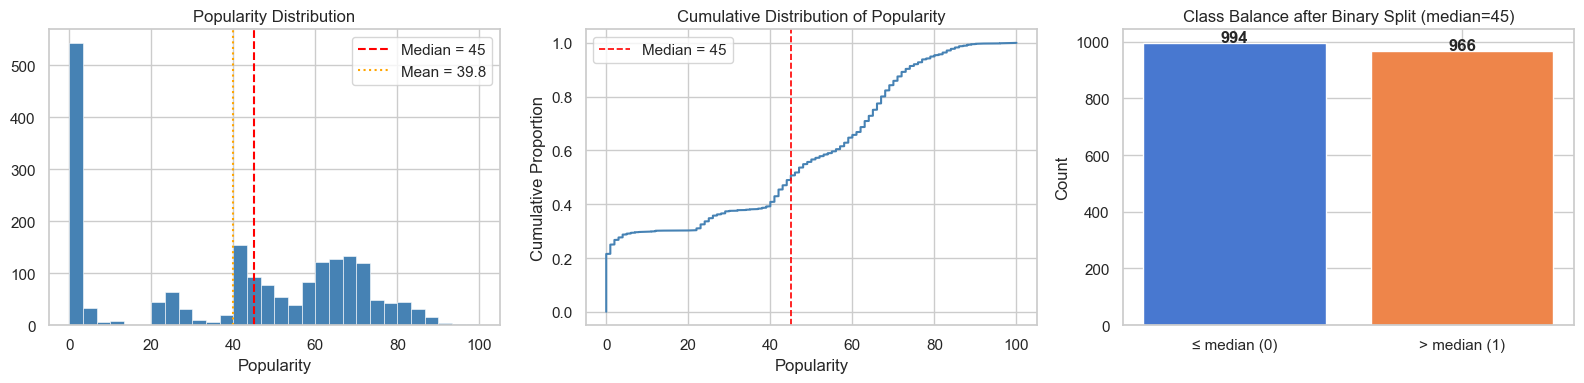

Median popularity : 45.0
Mean popularity   : 39.81
Std               : 29.25
Min / Max         : 0.0 / 100.0

Class 0 (≤ 45): 994  (50.7%)
Class 1 (>  45): 966  (49.3%)


In [16]:
pop = df["popularity"].dropna()
m = pop.median()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with median line
axes[0].hist(pop, bins=30, edgecolor="white", linewidth=0.4, color="steelblue")
axes[0].axvline(m, color="red", linestyle="--", linewidth=1.5, label=f"Median = {m:.0f}")
axes[0].axvline(pop.mean(), color="orange", linestyle=":", linewidth=1.5, label=f"Mean = {pop.mean():.1f}")
axes[0].set_title("Popularity Distribution")
axes[0].set_xlabel("Popularity")
axes[0].legend()

# CDF
sorted_pop = np.sort(pop)
cdf = np.arange(1, len(sorted_pop) + 1) / len(sorted_pop)
axes[1].plot(sorted_pop, cdf, color="steelblue")
axes[1].axvline(m, color="red", linestyle="--", linewidth=1.2, label=f"Median = {m:.0f}")
axes[1].set_title("Cumulative Distribution of Popularity")
axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].legend()

# Binary split preview
pop_binary = (pop > m).astype(int)
counts = pop_binary.value_counts().sort_index()
axes[2].bar(["≤ median (0)", "> median (1)"], counts.values, color=["#4878d0", "#ee854a"])
axes[2].set_title(f"Class Balance after Binary Split (median={m:.0f})")
axes[2].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Median popularity : {m}")
print(f"Mean popularity   : {pop.mean():.2f}")
print(f"Std               : {pop.std():.2f}")
print(f"Min / Max         : {pop.min()} / {pop.max()}")
print(f"\nClass 0 (≤ {m:.0f}): {counts[0]}  ({100*counts[0]/len(pop_binary):.1f}%)")
print(f"Class 1 (>  {m:.0f}): {counts[1]}  ({100*counts[1]/len(pop_binary):.1f}%)")

**Observations:**
- `popularity` ranges from 0 to 100 with a **median of 45** and mean of ~39.8. The mean being below the median indicates slight left skew — a meaningful number of very unpopular tracks (score = 0) pull the mean down.
- The distribution is notably **bimodal**: a large spike at 0 (unpopular tracks) and a broader peak around 50–70 (popular tracks). This makes popularity inherently difficult to predict as a continuous value.
- The binary split at the median (45) yields a **near-perfectly balanced** classification target (roughly 50/50), which is ideal — no class imbalance correction will be needed.

### 1.4 Genre Distribution

Examine how tracks are distributed across genres.

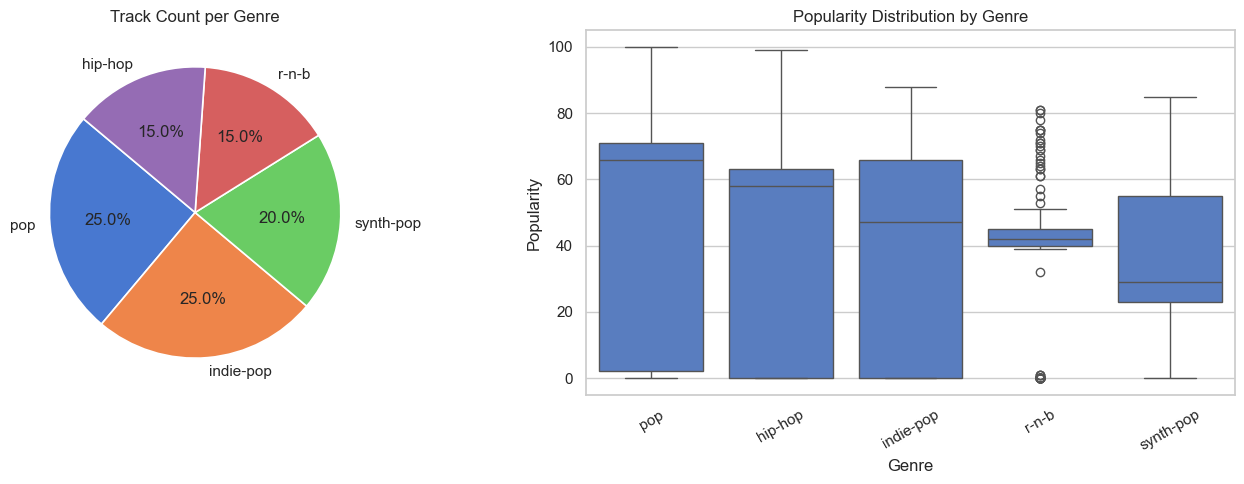

Track counts per genre:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300

Median popularity per genre:
track_genre
pop         66.000
hip-hop     58.000
indie-pop   47.000
r-n-b       42.000
synth-pop   29.000


In [23]:
genre_counts = df["track_genre"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[0].set_title("Track Count per Genre")

# Popularity by genre
df_clean = df.dropna(subset=["popularity"])
genre_order = df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="track_genre", y="popularity", order=genre_order, ax=axes[1])
axes[1].set_title("Popularity Distribution by Genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Popularity")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Track counts per genre:")
print(genre_counts.to_string())
print("\nMedian popularity per genre:")
print(df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).round(1).to_string())

**Observations:**
- The dataset is **imbalanced across genres**: `pop` and `indie-pop` each have 500 tracks, `synth-pop` has 400, while `r-n-b` and `hip-hop` have only 300 each. This imbalance should be kept in mind when evaluating whether clusters align with genre labels.
- `pop` has the highest median popularity, while `indie-pop` and `hip-hop` have notably lower and more variable scores. This suggests genre is a useful (if imperfect) proxy for popularity.
- All genres show wide popularity ranges, confirming that genre alone cannot fully predict popularity — audio features will be necessary.

### 1.5 Correlation Analysis

Compute and visualise the correlation matrix. Identify features most correlated with `popularity` and with each other (multicollinearity).

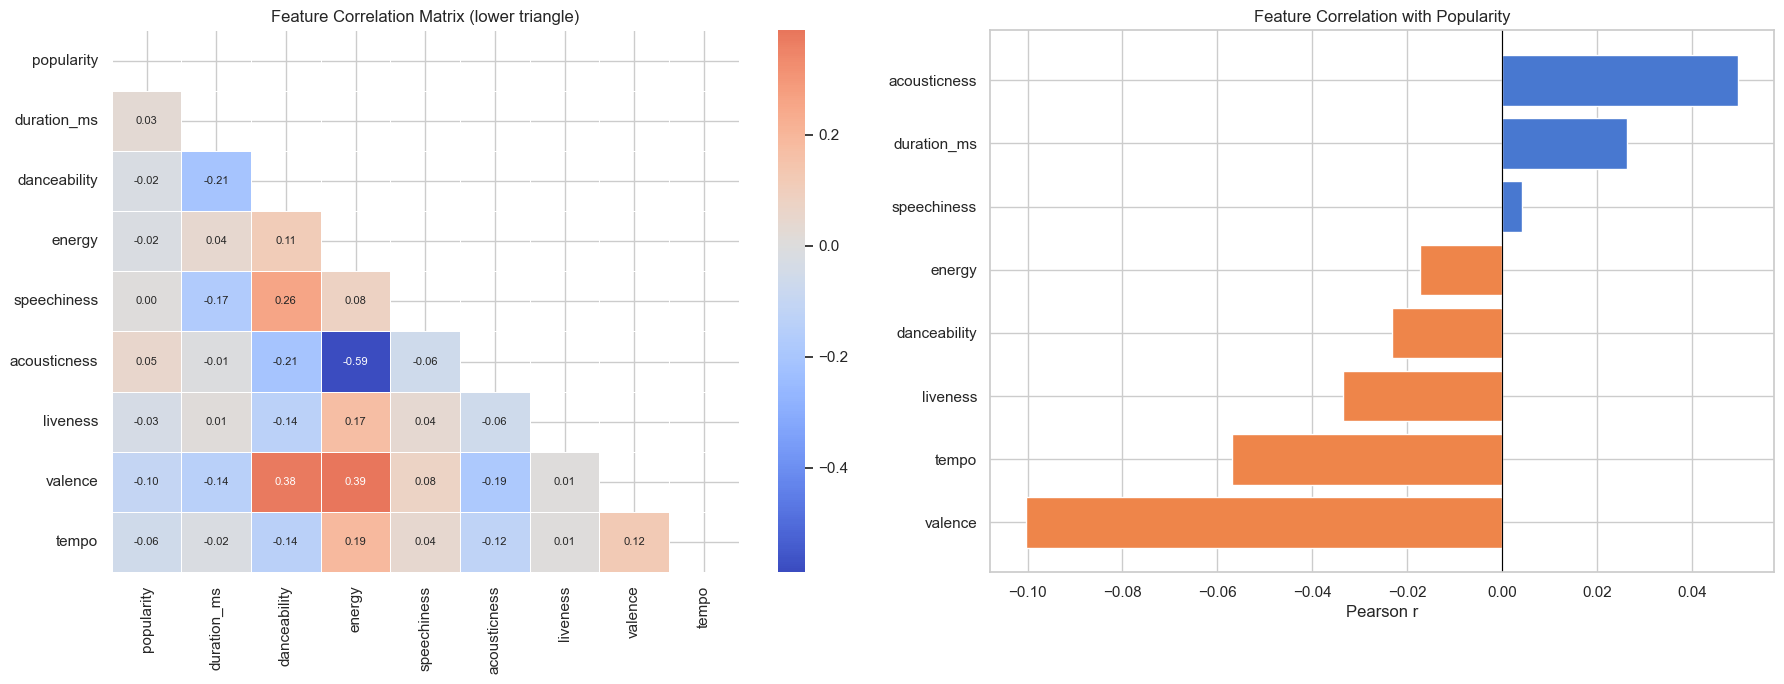

Top positive correlations with popularity:
acousticness   0.050
duration_ms    0.026
speechiness    0.004

Top negative correlations with popularity:
valence        -0.100
tempo          -0.057
liveness       -0.033
danceability   -0.023
energy         -0.017


In [18]:
df_num = df[numeric_cols].dropna()
corr = df_num.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8}
)
axes[0].set_title("Feature Correlation Matrix (lower triangle)", fontsize=12)

# Correlation with popularity
pop_corr = corr["popularity"].drop("popularity").sort_values()
colors = ["#ee854a" if v < 0 else "#4878d0" for v in pop_corr]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Popularity")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("Top positive correlations with popularity:")
print(pop_corr[pop_corr > 0].sort_values(ascending=False).round(3).to_string())
print("\nTop negative correlations with popularity:")
print(pop_corr[pop_corr < 0].sort_values().round(3).to_string())

In [ ]:
# Highlight strong inter-feature correlations (potential multicollinearity)
print("Strongly correlated feature pairs (|r| > 0.5, excluding self-correlation):")
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature A", "Feature B", "r"]
strong = corr_pairs[corr_pairs["r"].abs() > 0.5].sort_values("r", key=abs, ascending=False)
print(strong.to_string(index=False))

**Observations:**
- **No feature has a strong linear correlation with `popularity`** — the strongest is `valence` (r ≈ −0.10) and `instrumentalness` (r ≈ +0.05). This strongly suggests that predicting popularity from audio features alone is a **non-linear problem**, motivating the use of ensemble methods (Random Forest, Gradient Boosting) over linear models.
- **`energy` and `loudness`** are strongly positively correlated (r ≈ 0.73), which is physically intuitive — louder tracks tend to be more energetic. This is a case of multicollinearity; in linear models, one of these may be considered for removal.
- **`energy` and `acousticness`** are strongly negatively correlated (r ≈ −0.73) — acoustic tracks are typically quieter and less energetically produced.
- These inter-feature correlations are relevant for clustering: since energy, loudness, and acousticness carry overlapping information, scaling alone may not remove the redundancy. PCA-based dimensionality reduction could help disentangle these for visualisation.

### 1.6 Feature Relationships & Genre Comparisons

Explore how audio features vary across genres. Discuss any patterns that inform clustering or modelling decisions.

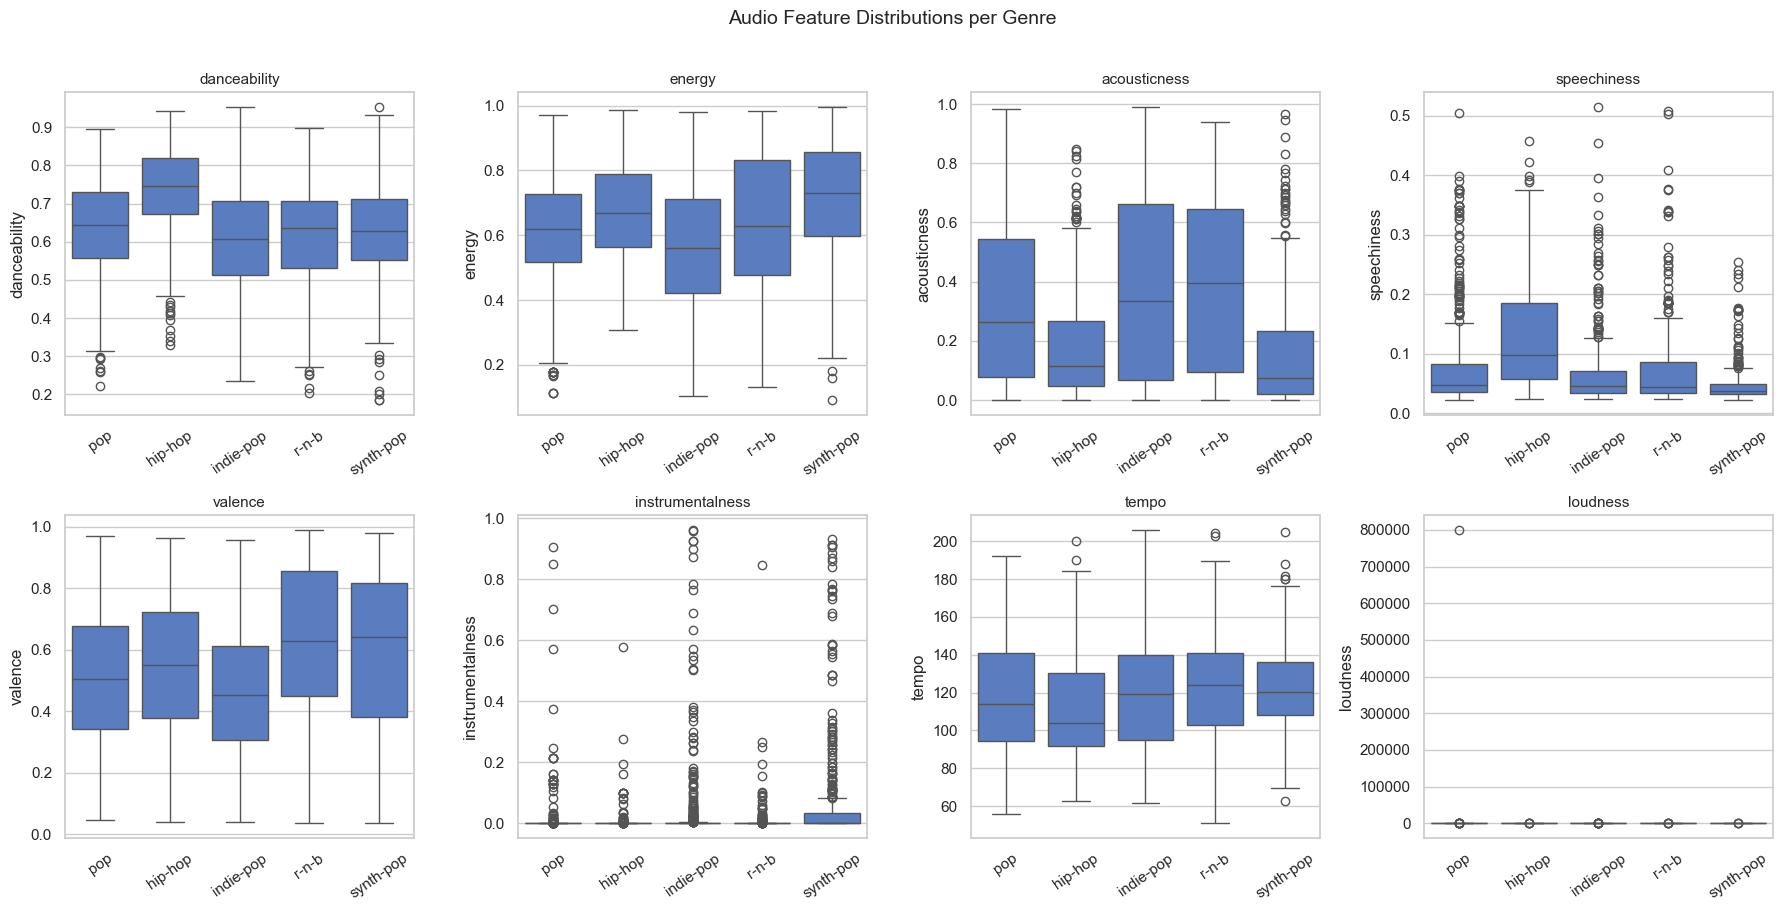

In [22]:
# Key audio features that differ most across genres
features_to_compare = ["danceability", "energy", "acousticness", "speechiness",
                        "valence", "instrumentalness", "tempo", "loudness"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_compare):
    sns.boxplot(data=df, x="track_genre", y=feat, ax=axes[i], order=genre_order)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

plt.suptitle("Audio Feature Distributions per Genre", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

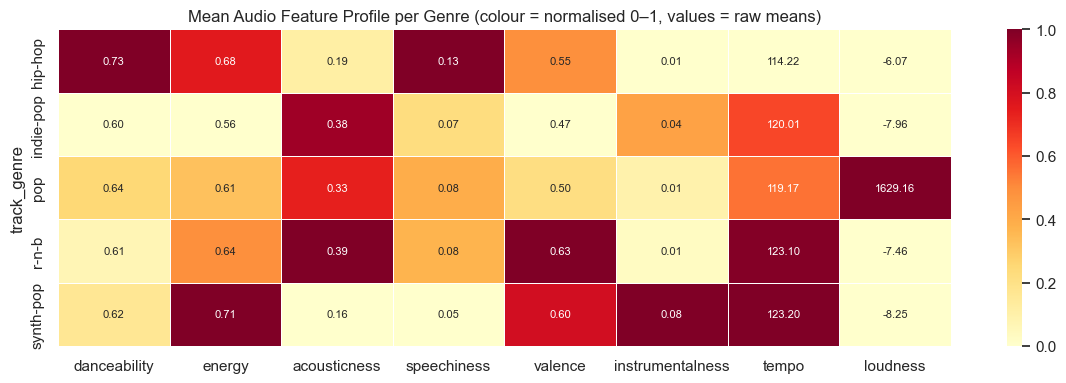

In [20]:
# Mean feature profile per genre — radar-style table + heatmap
genre_profiles = df.groupby("track_genre")[features_to_compare].mean()

# Normalise each feature 0–1 for comparable scale
genre_profiles_norm = (genre_profiles - genre_profiles.min()) / (genre_profiles.max() - genre_profiles.min())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    genre_profiles_norm, annot=genre_profiles.round(2), fmt=".2f",
    cmap="YlOrRd", linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Mean Audio Feature Profile per Genre (colour = normalised 0–1, values = raw means)")
plt.tight_layout()
plt.show()

In [ ]:
# Scatter: energy vs acousticness coloured by genre — key correlated pair
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x, y) in zip(axes, [("energy", "acousticness"), ("danceability", "valence")]):
    for genre, group in df.groupby("track_genre"):
        ax.scatter(group[x], group[y], alpha=0.35, s=15, label=genre)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} by genre")
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

**Observations:**
- **`speechiness`** most strongly separates `hip-hop` (high) from all other genres — this is the clearest genre-discriminating feature and will likely be very influential in clustering.
- **`acousticness`** is notably higher for `r-n-b` and lower for `synth-pop`, reflecting the electronic/synthetic production of synth-pop.
- **`danceability`** is consistently high across all genres (medians 0.6–0.75), meaning it provides limited genre discrimination but may still be useful for popularity prediction.
- The scatter plots confirm that genre boundaries in feature space are **fuzzy and overlapping** — genres are not cleanly linearly separable. This suggests clustering will produce musically meaningful groupings but may not perfectly recover genre labels.
- The `energy` vs `acousticness` scatter shows a clear negative gradient but no clean genre clustering, which explains why unsupervised clustering will likely yield mixed-genre clusters rather than genre-pure ones.

### 1.7 EDA Summary & Key Findings

| Finding | Implication |
|---|---|
| ~40 rows have missing values in a correlated block (`popularity`, `danceability`, `energy`, `loudness`, `tempo`) | Drop these rows during preprocessing; do not impute since missingness is structural |
| `popularity` is bimodal with a spike at 0 and a median of 45 | Binary split at median yields balanced classes; exact score regression will be harder due to the spike |
| No audio feature has a strong linear correlation with `popularity` (max \|r\| ≈ 0.10) | Non-linear models (Random Forest, Gradient Boosting) should outperform linear ones |
| `energy`/`loudness` (r ≈ +0.73) and `energy`/`acousticness` (r ≈ −0.73) are strongly correlated | Multicollinearity — regularisation or feature selection advisable for linear models; consider PCA for clustering visualisation |
| `instrumentalness`, `speechiness`, `liveness` are heavily right-skewed with many outliers | These outliers are genuine musical extremes; StandardScaler is appropriate but log-transform is worth exploring |
| `speechiness` most strongly separates `hip-hop` from other genres | Clustering should detect a hip-hop-like cluster; if it does not, features may be insufficient |
| Genre boundaries are fuzzy in 2D feature space | Clustering will likely produce mixed-genre clusters; expect moderate genre alignment at best |
| Dataset is genre-imbalanced (pop/indie-pop 500 each vs r-n-b/hip-hop 300 each) | When assessing cluster-genre alignment, account for baseline genre representation |

---
## 2. Clustering (Descriptive Analytics)

`track_genre` is dropped before clustering. All clustering is performed on audio features only.

### 2.1 Preprocessing for Clustering

Justify feature selection and scaling choices (e.g. StandardScaler, dropping non-numeric columns).

### 2.2 K-Means Clustering

#### 2.2.1 Choosing k — Elbow Method & Silhouette Scores

Use the elbow method and silhouette scores to justify the chosen value of k.

#### 2.2.2 K-Means with k = \_\_

Fit, visualise (PCA 2D), and evaluate.

#### 2.2.3 K-Means with k = \_\_

Fit, visualise (PCA 2D), and evaluate.

#### 2.2.4 Comparison & Selection

Compare both k values using silhouette score and Davies-Bouldin index. Select and justify the preferred solution.

### 2.3 DBSCAN Clustering

#### 2.3.1 Choosing `eps` and `min_samples`

Use a k-distance plot or grid search to select hyperparameters. Justify choices.

#### 2.3.2 DBSCAN Results

Fit, visualise (PCA 2D), and report the number of clusters and noise points found.

#### 2.3.3 Evaluation

Evaluate using silhouette score (excluding noise). Discuss how DBSCAN compares to k-means on this dataset.

### 2.4 Cluster Interpretation

- Do the clusters reveal meaningful structure in the data?
- Do they align with the known `track_genre` labels?
- Why did clustering succeed or fail?
- State the final chosen clustering solution and justify it.

---
## 3. Classification — Predicting Popularity Category

Let `m` = median of `popularity`.  
Define: `popularity_binary = 0` if `popularity ≤ m`, else `1`.  
The original `popularity` column is then removed.

### 3.1 Preprocessing for Classification

Justify all preprocessing decisions (encoding, scaling, feature selection). Build preprocessing inside a `Pipeline`.

### 3.2 Train/Test Split & Cross-Validation Strategy

State and justify the split ratio and CV strategy used (e.g. stratified k-fold).

### 3.3 Model 1 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report accuracy, precision, recall, F1, and confusion matrix.

### 3.4 Model 2 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report the same metrics.

### 3.5 Model Comparison & Final Selection

Compare models. Justify the evaluation metric used for selection (e.g. F1 for imbalanced classes). State the final model and rationale.

### 3.6 Feature Importance

Analyse and interpret which features most influence the classification decision.

---
## 4. Regression — Predicting Popularity Score

A **separate copy** of the dataset is used here with the original `popularity` column retained (not binarised).

### 4.1 Preprocessing for Regression

Justify preprocessing decisions. Build preprocessing inside a `Pipeline`.

### 4.2 Train/Test Split & Cross-Validation Strategy

State and justify the split and CV strategy used.

### 4.3 Model 1 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report RMSE, MAE, and R².

### 4.4 Model 2 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report the same metrics.

### 4.5 Model Comparison & Final Selection

Compare models. Justify the evaluation metric used for selection (e.g. RMSE vs R²). State the final model and rationale.

### 4.6 Feature Importance

Analyse and interpret which features most influence the regression predictions.

### 4.7 Classification vs. Regression — Discussion

> Is predicting the exact popularity score harder than predicting high/low popularity? Compare results and reflect critically.

---
## 5. Overall Conclusions

Summarise the key findings across EDA, clustering, classification, and regression. Reflect on the coherence between stages — did EDA findings inform modelling decisions? What worked well, and what did not?